# Creation of test models

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import v2
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset
from collections import defaultdict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

cuda


In [2]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## Verification of images

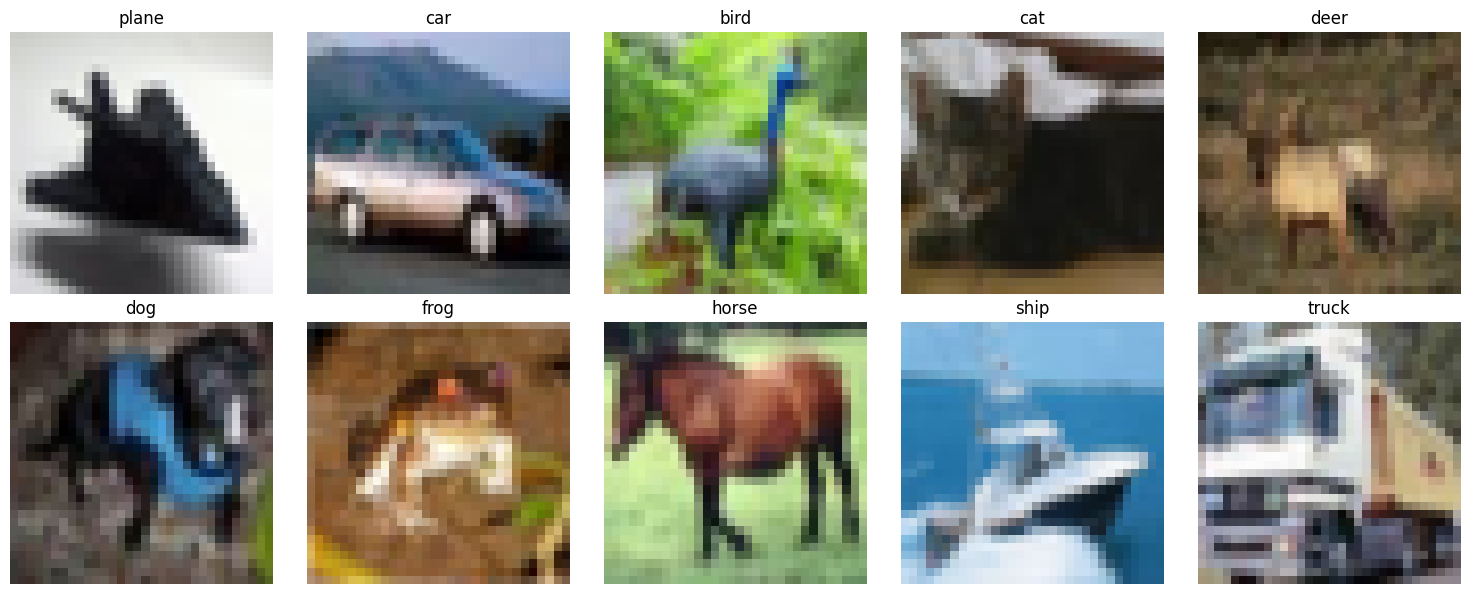

In [3]:
class_samples = {}
for img, label in trainset:
    if label not in class_samples:
        class_samples[label] = img
    if len(class_samples) == len(classes):
        break

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, (label, img) in enumerate(sorted(class_samples.items())):
    ax = axes[idx // 5, idx % 5]
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616))])

full_trainset  = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

targets = np.array(full_trainset.targets)
perc_val = 15
val_per_class = perc_val*50
train_indices = []
val_indices = []

for class_id in range(10):
    class_indices = np.where(targets == class_id)[0]

    # deterministic shuffle
    rng = np.random.default_rng(SEED + class_id)
    rng.shuffle(class_indices)

    val_class_indices = class_indices[:val_per_class]
    train_class_indices = class_indices[val_per_class:]

    val_indices.extend(val_class_indices)
    train_indices.extend(train_class_indices)


trainset = Subset(full_trainset, train_indices)
valset = Subset(full_trainset, val_indices)

batch_size = 64

valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

In [5]:
val_targets = targets[val_indices]

for i in range(10):
    print(f"Class {i}: {(val_targets == i).sum()}")

Class 0: 750
Class 1: 750
Class 2: 750
Class 3: 750
Class 4: 750
Class 5: 750
Class 6: 750
Class 7: 750
Class 8: 750
Class 9: 750


### Saving train and val split for reproducibility

In [ ]:
train_indices = np.array(train_indices)
val_indices = np.array(val_indices)

torch.save(
    {
        "train_indices": train_indices,
        "val_indices": val_indices,
        "seed": SEED
    },
    "cifar10_split.pt"
)
print("Split saved.")

In [ ]:
# To load
'''
from torch.utils.data import Subset

split = torch.load("cifar10_split.pt")

train_indices = split["train_indices"]
val_indices = split["val_indices"]

trainset = Subset(full_trainset, train_indices)
valset = Subset(full_trainset, val_indices)

valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
'''

## Creation of Model Class

In [6]:
# ============================================================================
# 1. PERCEPTRON MULTICAMADAS (MLP)
# ============================================================================
class CIFAR10MLP(nn.Module):
    """
    Rede de neurónios densa para isolar o efeito da poda em ligações totalmente 
    conectadas (Fully Connected), afetando diretamente as matrizes de pesos.
    """
    def __init__(self, input_dim=3 * 32 * 32, num_classes=10):
        super(CIFAR10MLP, self).__init__()
        
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_dim, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        return self.classifier(x)


In [7]:
# ============================================================================
# 2. VISUAL GEOMETRY GROUP (VGG-11 adaptada para CIFAR-10)
# ============================================================================
class CIFAR10VGG(nn.Module):
    """
    Rede convolucional profunda (baseada na VGG-11) ideal para testar a poda 
    estruturada de filtros e canais devido à sua elevada densidade de parâmetros.
    """
    def __init__(self, num_classes=10):
        super(CIFAR10VGG, self).__init__()
        
        # Configuração da VGG-11: números representam canais de saída, 'M' é MaxPool
        # Ajustada para CIFAR-10 para manter mapas de características viáveis (32x32 -> 1x1)
        self.cfg = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']
        
        self.features = self._make_layers(self.cfg)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        
        # Classificador linear simplificado para o CIFAR-10 pós-convoluções
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x
        
    def _make_layers(self, cfg):
        layers = []
        in_channels = 3  # Entrada RGB do CIFAR-10
        
        for x in cfg:
            if x == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                layers += [
                    nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                    nn.BatchNorm2d(x), # Crucial para estabilidade antes/pós poda
                    nn.ReLU(inplace=True)
                ]
                in_channels = x
                
        return nn.Sequential(*layers)

In [8]:
# Simulação de um lote (batch) de 4 imagens do CIFAR-10
mock_input = torch.randn(4, 3, 32, 32)

mlp_model = CIFAR10MLP()
vgg_model = CIFAR10VGG()

print("## Verificação das Arquiteturas ##")
print(f"MLP Output Shape: {mlp_model(mock_input).shape}")
print(f"VGG Output Shape: {vgg_model(mock_input).shape}")

mlp_total_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
vgg_total_params = sum(p.numel() for p in vgg_model.parameters() if p.requires_grad)

print("\n## Densidade de Parâmetros (Alvos de Poda) ##")
print(f"Total de parâmetros treináveis no MLP: {mlp_total_params:,}")
print(f"Total de parâmetros treináveis na VGG: {vgg_total_params:,}")

## Verificação das Arquiteturas ##
MLP Output Shape: torch.Size([4, 10])
VGG Output Shape: torch.Size([4, 10])

## Densidade de Parâmetros (Alvos de Poda) ##
Total de parâmetros treináveis no MLP: 8,928,778
Total de parâmetros treináveis na VGG: 9,493,770


## Training of Models

In [9]:
def train_model(model, trainloader, valloader, epochs=10, lr=1e-3):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):

        # -----------------
        # TRAIN
        # -----------------
        model.train()
        running_loss = 0.0

        for images, labels in tqdm(trainloader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(trainloader)
        train_losses.append(train_loss)

        # -----------------
        # VALIDATION
        # -----------------
        model.eval()

        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in valloader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = running_val_loss / len(valloader)
        accuracy = 100 * correct / total

        val_losses.append(val_loss)
        val_accuracies.append(accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {accuracy:.2f}%"
        )

    return model, train_losses, val_losses, val_accuracies

In [10]:
def evaluate_model(model, loader, device):
    model.eval()

    y_true = []
    y_pred = []
    y_probs = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # predicted class
            _, predicted = torch.max(outputs, 1)

            # probabilities
            probs = torch.softmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    return y_true, y_pred, y_probs

In [67]:
mlp_model = CIFAR10MLP()

mlp_model, mlp_train_loss, mlp_val_loss, mlp_acc = train_model(
    mlp_model,
    trainloader,
    valloader,
    epochs=20,
    lr=1e-3
)

100%|██████████| 665/665 [00:14<00:00, 46.00it/s] 


100%|██████████| 665/665 [00:14<00:00, 46.00it/s] 


Epoch [1/20] Train Loss: 1.7052 | Val Loss: 1.5074 | Val Acc: 46.11%


100%|██████████| 665/665 [00:14<00:00, 46.06it/s] 


100%|██████████| 665/665 [00:14<00:00, 46.00it/s] 


...

Epoch [18/20] Train Loss: 0.7863 | Val Loss: 1.2716 | Val Acc: 58.32%


100%|██████████| 665/665 [00:14<00:00, 45.64it/s] 


Epoch [19/20] Train Loss: 0.7478 | Val Loss: 1.3302 | Val Acc: 57.73%


100%|██████████| 665/665 [00:14<00:00, 45.43it/s] 


Epoch [20/20] Train Loss: 0.7302 | Val Loss: 1.3149 | Val Acc: 58.04%


In [69]:
vgg_model = CIFAR10VGG()

vgg_model, vgg_train_loss, vgg_val_loss, vgg_acc = train_model(
    vgg_model,
    trainloader,
    valloader,
    epochs=20,
    lr=1e-4
)

100%|██████████| 665/665 [00:20<00:00, 32.80it/s]


100%|██████████| 665/665 [00:20<00:00, 32.80it/s]


Epoch [1/20] Train Loss: 1.2455 | Val Loss: 0.9813 | Val Acc: 65.32%


100%|██████████| 665/665 [00:20<00:00, 32.63it/s]


100%|██████████| 665/665 [00:20<00:00, 32.80it/s]


...

Epoch [18/20] Train Loss: 0.0611 | Val Loss: 1.0506 | Val Acc: 78.71%


100%|██████████| 665/665 [00:20<00:00, 32.52it/s]


Epoch [19/20] Train Loss: 0.0429 | Val Loss: 1.1004 | Val Acc: 78.20%


100%|██████████| 665/665 [00:20<00:00, 31.82it/s]


Epoch [20/20] Train Loss: 0.0478 | Val Loss: 1.0234 | Val Acc: 79.04%


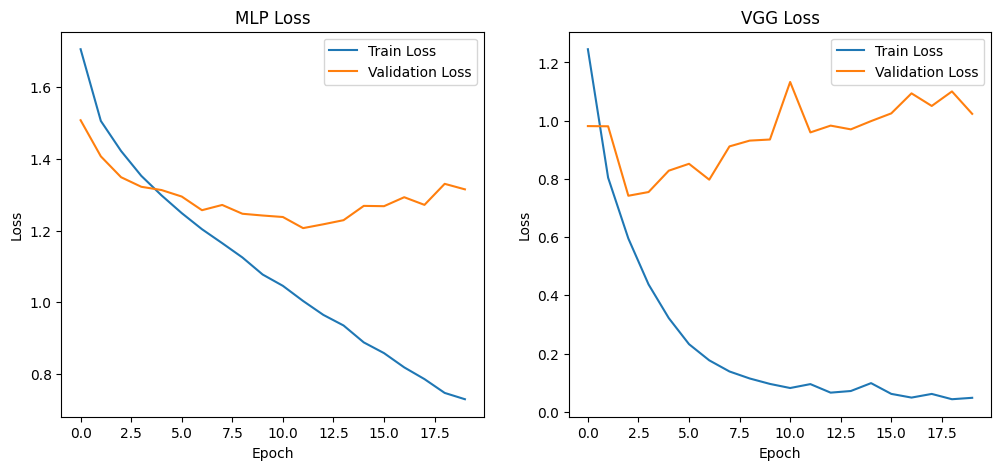

In [70]:
plt.figure(figsize=(12,5))

# MLP
plt.subplot(1,2,1)
plt.plot(mlp_train_loss, label="Train Loss")
plt.plot(mlp_val_loss, label="Validation Loss")
plt.title("MLP Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# VGG
plt.subplot(1,2,2)
plt.plot(vgg_train_loss, label="Train Loss")
plt.plot(vgg_val_loss, label="Validation Loss")
plt.title("VGG Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Evaluation of models

In [13]:
mlp_true, mlp_pred, mlp_probs = evaluate_model(
    mlp_model,
    testloader,
    device
)
vgg_true, vgg_pred, vgg_probs = evaluate_model(
    vgg_model,
    testloader,
    device
)

In [14]:
def compute_metrics(y_true, y_pred):

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),

        "balanced_accuracy":
            balanced_accuracy_score(y_true, y_pred),

        "precision_macro":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "precision_weighted":
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "recall_macro":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "recall_weighted":
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "f1_macro":
            f1_score(
                y_true,
                y_pred,
                average="macro"
            ),

        "f1_weighted":
            f1_score(
                y_true,
                y_pred,
                average="weighted"
            ),

        "cohen_kappa":
            cohen_kappa_score(y_true, y_pred),

        "mcc":
            matthews_corrcoef(y_true, y_pred)
    }

    return metrics

In [15]:
mlp_metrics = compute_metrics(
    mlp_true,
    mlp_pred
)

for key, value in mlp_metrics.items():
    print(f"{key}: {value:.4f}")

accuracy: 0.5732
balanced_accuracy: 0.5732
precision_macro: 0.5799
precision_weighted: 0.5799
recall_macro: 0.5732
recall_weighted: 0.5732
f1_macro: 0.5752
f1_weighted: 0.5752
cohen_kappa: 0.5258
mcc: 0.5261


In [16]:
vgg_metrics = compute_metrics(
    vgg_true,
    vgg_pred
)

for key, value in vgg_metrics.items():
    print(f"{key}: {value:.4f}")

accuracy: 0.7852
balanced_accuracy: 0.7852
precision_macro: 0.7906
precision_weighted: 0.7906
recall_macro: 0.7852
recall_weighted: 0.7852
f1_macro: 0.7838
f1_weighted: 0.7838
cohen_kappa: 0.7613
mcc: 0.7623


In [17]:
print(classification_report(
    mlp_true,
    mlp_pred,
    target_names=classes
))

              precision    recall  f1-score   support

       plane       0.64      0.65      0.65      1000
         car       0.72      0.65      0.68      1000
        bird       0.48      0.47      0.47      1000
         cat       0.37      0.43      0.40      1000
        deer       0.48      0.54      0.50      1000
         dog       0.49      0.45      0.47      1000
        frog       0.59      0.65      0.62      1000
       horse       0.69      0.60      0.64      1000
        ship       0.68      0.71      0.69      1000
       truck       0.66      0.58      0.62      1000

    accuracy                           0.57     10000
   macro avg       0.58      0.57      0.58     10000
weighted avg       0.58      0.57      0.58     10000



In [18]:
print(classification_report(
    vgg_true,
    vgg_pred,
    target_names=classes
))

              precision    recall  f1-score   support

       plane       0.73      0.88      0.80      1000
         car       0.94      0.85      0.89      1000
        bird       0.80      0.62      0.70      1000
         cat       0.68      0.57      0.62      1000
        deer       0.80      0.71      0.75      1000
         dog       0.66      0.78      0.71      1000
        frog       0.78      0.87      0.83      1000
       horse       0.74      0.87      0.80      1000
        ship       0.87      0.86      0.87      1000
       truck       0.91      0.84      0.87      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.78     10000
weighted avg       0.79      0.79      0.78     10000



In [19]:
def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8,8))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes
    )
    disp.plot(
        cmap="Blues",
        ax=ax,
        xticks_rotation=45,
        colorbar=False
    )
    plt.title(title)
    plt.show()

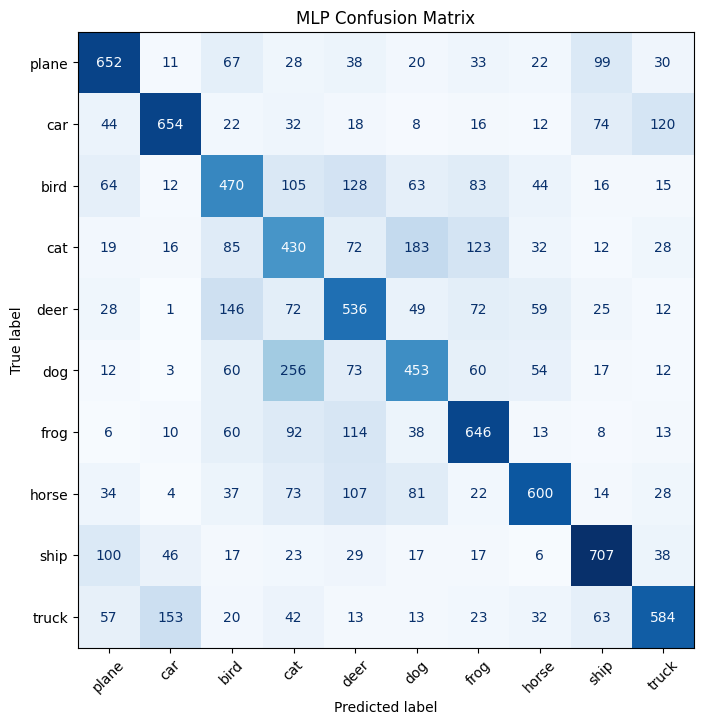

In [20]:
plot_confusion_matrix(
    mlp_true,
    mlp_pred,
    classes,
    "MLP Confusion Matrix"
)

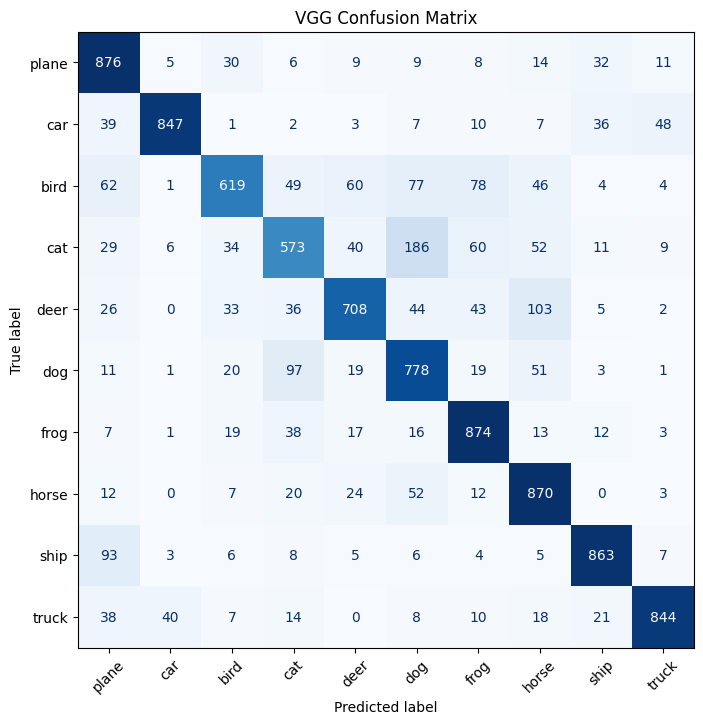

In [21]:
plot_confusion_matrix(
    vgg_true,
    vgg_pred,
    classes,
    "VGG Confusion Matrix"
)

In [ ]:
def show_predictions(model, loader, n_images=8):
    model.eval()
    images, labels = next(iter(loader))
    images = images[:n_images].to(device)
    labels = labels[:n_images]
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    images = images.cpu()
    fig, axes = plt.subplots(1, n_images, figsize=(16,4))
    for i in range(n_images):
        img = images[i]

        # unnormalize
        img = img * 0.5 + 0.5
        img = img.permute(1,2,0)

        axes[i].imshow(img)
        axes[i].axis("off")

        true_label = classes[labels[i]]
        pred_label = classes[predicted[i]]

        color = "green" if labels[i] == predicted[i] else "red"

        axes[i].set_title(
            f"T:{true_label}\nP:{pred_label}",
            color=color,
            fontsize=9
        )

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39153773..1.5471395].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.4979502].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4629833..1.535427].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22441113..1.4005105].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4391681..1.2814069].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45793372..1.1802653].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.486

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39153773..1.5471395].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.4979502].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4629833..1.535427].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22441113..1.4005105].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4391681..1.2814069].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45793372..1.1802653].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.486

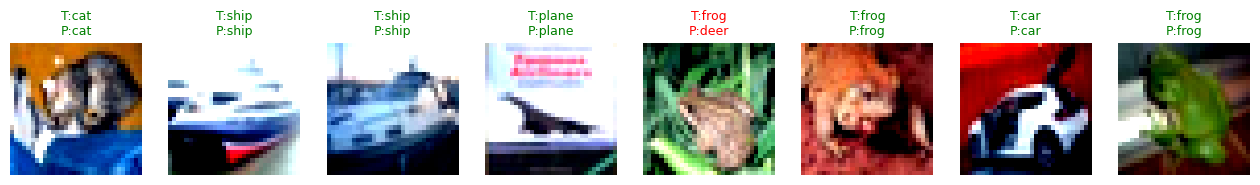

In [73]:
show_predictions(mlp_model, testloader)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39153773..1.5471395].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.4979502].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4629833..1.535427].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22441113..1.4005105].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4391681..1.2814069].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45793372..1.1802653].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.486

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39153773..1.5471395].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.4979502].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4629833..1.535427].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22441113..1.4005105].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4391681..1.2814069].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45793372..1.1802653].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.486

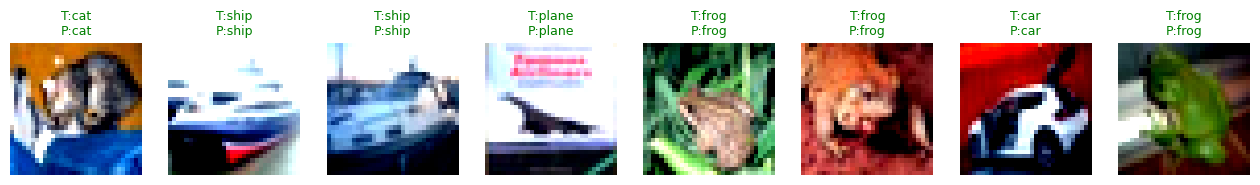

In [74]:
show_predictions(vgg_model, testloader)

### Saving and loading of the models

In [ ]:
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

PATH_MLP = models_dir / 'cifar_mlp.pt'
PATH_VGG = models_dir / 'cifar_vgg.pt'

In [ ]:
torch.save(vgg_model, PATH_VGG)
torch.save(mlp_model, PATH_MLP)

In [12]:
mlp_model = torch.load(PATH_MLP, weights_only=False)
mlp_model.eval()
vgg_model = torch.load(PATH_VGG, weights_only=False)
vgg_model.eval()

CIFAR10VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPo